# 전처리 & 데이터 준비

**목표**: 학습 노트북들이 공통으로 쓸 재료를 만들어 디스크에 저장한다.

**산출물**:
1. `masks/` — polygon을 raster로 변환한 uint8 PNG 200장 (픽셀값 = 클래스 ID 0~6)
2. `class_mapping.json` — Superannotate 내부 ID → 학습용 0~6 label 매핑
3. `splits.json` — Test 30 / Dev 170 split + 5-fold 인덱스
4. `preprocessing_mask_check.png` — 변환 결과 샘플 5장 검증

**원칙**: 이 노트북은 **한 번만 실행**하면 된다. 학습 노트북에서는 결과물만 읽어다 쓴다.

**전제 확인 사항**:
- Scene 연속성 없음 확정 (EDA에서 육안 확인) → 단순 stratified random split
- Stratify 기준: Moveable 객체 수 구간 (few / medium / many)

## 1. 환경 설정

In [1]:
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import KFold, train_test_split
from tqdm.auto import tqdm

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로
BASE = Path('.').resolve()   # 이 노트북이 있는 train/ 폴더에서 실행
DATA_DIR = BASE / 'www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset'
JSON_PATH = DATA_DIR / 'COCO_motorcycle (pixel).json'
IMG_DIR = DATA_DIR / 'images'

# 출력 경로
MASKS_DIR = BASE / 'masks'
SPLITS_PATH = BASE / 'splits.json'
CLASS_MAP_PATH = BASE / 'class_mapping.json'
MASKS_DIR.mkdir(exist_ok=True)

print(f'입력 JSON : {JSON_PATH.exists()}  ← {JSON_PATH.name}')
print(f'이미지 폴더: {IMG_DIR.exists()}')
print(f'마스크 출력: {MASKS_DIR}')
print(f'Split 출력: {SPLITS_PATH}')

입력 JSON : True  ← COCO_motorcycle (pixel).json
이미지 폴더: True
마스크 출력: C:\Users\akals\Downloads\archive\masks
Split 출력: C:\Users\akals\Downloads\archive\splits.json


## 2. 클래스 ID Remapping

JSON 원본의 `category_id`는 Superannotate 내부 ID (`1323880~1329681`)로 비표준. 학습에는 0~N 연속 정수가 필요하므로 remap한다.

| 라벨 | 클래스명 | 원본 ID |
|---:|---|---:|
| 0 | Background | — |
| 1 | Undrivable | 1323880 |
| 2 | Road | 1323881 |
| 3 | Lane Mark | 1323882 |
| 4 | Moveable | 1323884 |
| 5 | My bike | 1323885 |
| 6 | Rider | 1329681 |

Background는 polygon이 없는 모든 픽셀 (초기값 0으로 자동 할당).

In [2]:
with open(JSON_PATH, encoding='utf-8') as f:
    coco = json.load(f)

# 학습용 매핑 (원본 ID → 0~6 label)
cat_id_to_label = {
    1323880: 1,  # Undrivable
    1323881: 2,  # Road
    1323882: 3,  # Lane Mark
    1323884: 4,  # Moveable
    1323885: 5,  # My bike
    1329681: 6,  # Rider
}
label_to_name = {
    0: 'Background', 1: 'Undrivable', 2: 'Road', 3: 'Lane Mark',
    4: 'Moveable', 5: 'My bike', 6: 'Rider',
}
NUM_CLASSES = 7

# JSON의 categories와 매핑이 일치하는지 검증
json_cat_ids = {c['id'] for c in coco['categories']}
missing = json_cat_ids - set(cat_id_to_label.keys())
extra = set(cat_id_to_label.keys()) - json_cat_ids
assert not missing, f'매핑 누락: {missing}'
assert not extra, f'잘못된 매핑: {extra}'
print(f'매핑 검증 OK ({len(cat_id_to_label)}개 클래스)')

# 저장
with open(CLASS_MAP_PATH, 'w', encoding='utf-8') as f:
    json.dump({
        'cat_id_to_label': {str(k): v for k, v in cat_id_to_label.items()},
        'label_to_name': {str(k): v for k, v in label_to_name.items()},
        'num_classes': NUM_CLASSES,
    }, f, ensure_ascii=False, indent=2)
print(f'저장: {CLASS_MAP_PATH.name}')

매핑 검증 OK (6개 클래스)
저장: class_mapping.json


## 3. Polygon → Raster Mask 변환

JSON의 polygon을 매 epoch마다 렌더링하면 느림 (vertex가 평균 수천 개). 한 번에 PNG로 구워서 저장.

**중첩 처리**: 큰 영역부터 먼저 찍고 작은 영역이 덮어쓰는 순서. 이러면 예를 들어 Road 위에 올라탄 Rider가 제대로 Rider로 라벨됨.

In [3]:
def create_mask(img_meta, annotations, cat_id_to_label):
    """한 이미지의 polygon 어노테이션들을 단일 raster mask로 변환."""
    H, W = img_meta['height'], img_meta['width']
    mask = np.zeros((H, W), dtype=np.uint8)  # 초기값 0 = Background

    # 면적 큰 순으로 정렬 (큰 영역이 먼저, 작은 영역이 나중에 덮어씀)
    anns_sorted = sorted(annotations, key=lambda a: -a.get('area', 0))

    for ann in anns_sorted:
        label = cat_id_to_label.get(ann['category_id'])
        if label is None:
            continue
        segs = ann['segmentation']
        if not isinstance(segs, list):
            continue  # RLE는 이 데이터셋에 없음
        for poly in segs:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts.astype(np.int32)], int(label))
    return mask

# 이미지별로 어노테이션 그룹화
img_to_anns = defaultdict(list)
for ann in coco['annotations']:
    img_to_anns[ann['image_id']].append(ann)

print(f'이미지 수         : {len(coco["images"])}')
print(f'어노테이션 있는 수: {len(img_to_anns)}')
print(f'총 어노테이션    : {len(coco["annotations"])}')

이미지 수         : 200
어노테이션 있는 수: 200
총 어노테이션    : 2305


In [4]:
# 200장 전부 변환 + 저장. 이미지당 메타데이터도 수집 (Split에서 사용)
mask_metadata = []
skipped = []

for img_meta in tqdm(coco['images'], desc='마스크 생성'):
    # 실제 파일이 있는지 확인 (EDA에서 매칭 검증됨, 방어적으로 한 번 더)
    orig_path = IMG_DIR / img_meta['file_name']
    if not orig_path.exists():
        skipped.append(img_meta['file_name'])
        continue

    anns = img_to_anns.get(img_meta['id'], [])
    mask = create_mask(img_meta, anns, cat_id_to_label)

    # 원본과 같은 파일명으로 masks/ 에 저장
    mask_path = MASKS_DIR / img_meta['file_name']
    Image.fromarray(mask, mode='L').save(mask_path)

    # 이 이미지의 특성 수집 (Stratify용)
    mask_metadata.append({
        'image_id': img_meta['id'],
        'file_name': img_meta['file_name'],
        'height': img_meta['height'],
        'width': img_meta['width'],
        'n_objects': len(anns),
        'moveable_count': sum(1 for a in anns if a['category_id'] == 1323884),
        'lane_mark_count': sum(1 for a in anns if a['category_id'] == 1323882),
        'present_classes': sorted({cat_id_to_label[a['category_id']] for a in anns if a['category_id'] in cat_id_to_label}),
    })

print(f'\n변환 완료: {len(mask_metadata)}장')
if skipped:
    print(f'누락 (실제 파일 없음): {len(skipped)}장')
    print(' ', skipped[:5], '...' if len(skipped) > 5 else '')
print(f'저장 위치: {MASKS_DIR}')

마스크 생성:   0%|          | 0/200 [00:00<?, ?it/s]


변환 완료: 200장
저장 위치: C:\Users\akals\Downloads\archive\masks


## 4. 변환 결과 검증 (샘플 5장)

마스크가 원본 이미지와 올바르게 맞아떨어지는지 눈으로 확인. **이 셀이 가장 중요** — 여기서 이상하면 뒤 학습이 다 망함.

컬러 팔레트는 `tab10` (JSON 원본 팔레트가 구분 안 돼서 EDA에서 지적한 문제).

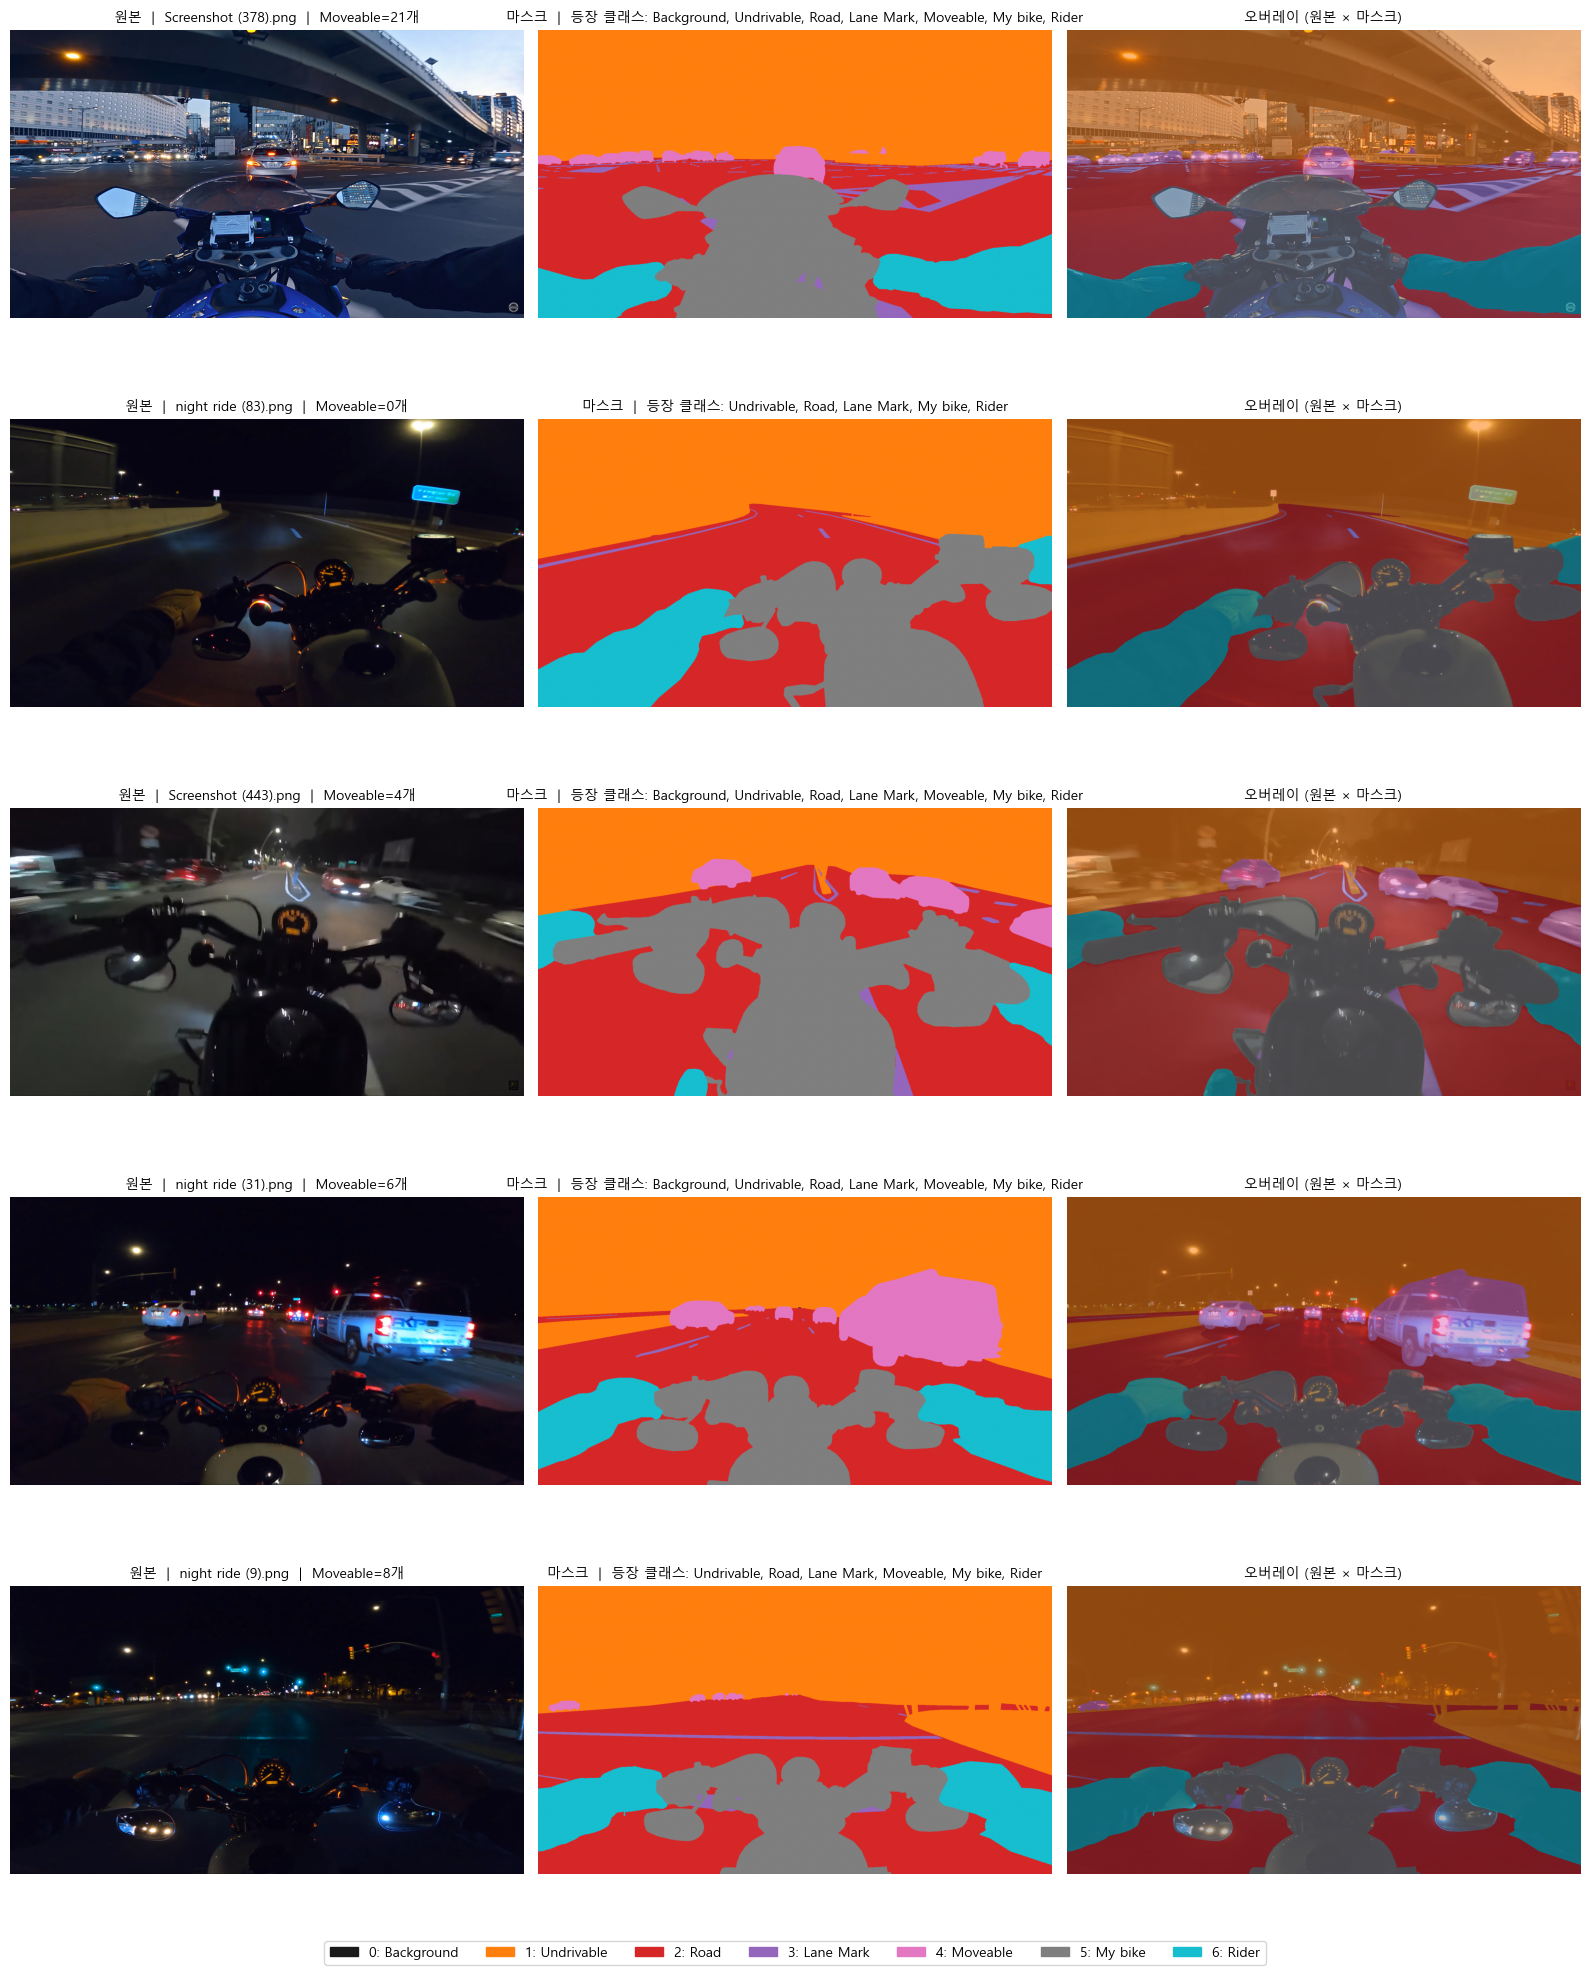

저장: preprocessing_mask_check.png


In [5]:
import random
random.seed(42)

# 시각화용 팔레트 (학습과 무관, 발표·디버깅 전용)
palette = plt.cm.tab10(np.linspace(0, 0.9, NUM_CLASSES))[:, :3]  # (7, 3) RGB [0,1]
palette[0] = [0.1, 0.1, 0.1]  # Background은 어둡게

def mask_to_rgb(mask):
    """uint8 단일 채널 mask → RGB 이미지 [0,1]."""
    return palette[mask]

# 다양한 케이스 샘플링: Moveable 많은 것 1장, 적은 것 1장, 랜덤 3장
sorted_by_mv = sorted(mask_metadata, key=lambda m: m['moveable_count'])
samples = [sorted_by_mv[-1], sorted_by_mv[0]]  # 최다 + 최소
samples += random.sample(mask_metadata, 3)

fig, axes = plt.subplots(len(samples), 3, figsize=(16, 4*len(samples)))
for row, meta in enumerate(samples):
    orig = np.array(Image.open(IMG_DIR / meta['file_name']).convert('RGB'))
    mask = np.array(Image.open(MASKS_DIR / meta['file_name']))
    mask_rgb = mask_to_rgb(mask)
    overlay = np.clip(orig / 255.0 * 0.45 + mask_rgb * 0.55, 0, 1)

    classes_here = sorted(np.unique(mask).tolist())
    class_str = ', '.join(label_to_name[c] for c in classes_here)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'원본  |  {meta["file_name"]}  |  Moveable={meta["moveable_count"]}개', fontsize=10)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(mask_rgb)
    axes[row, 1].set_title(f'마스크  |  등장 클래스: {class_str}', fontsize=10)
    axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('오버레이 (원본 × 마스크)', fontsize=10)
    axes[row, 2].axis('off')

legend_handles = [mpatches.Patch(color=palette[i], label=f'{i}: {label_to_name[i]}') for i in range(NUM_CLASSES)]
fig.legend(handles=legend_handles, loc='lower center', ncol=NUM_CLASSES, bbox_to_anchor=(0.5, -0.01), fontsize=10)

plt.tight_layout()
plt.savefig(BASE / 'preprocessing_mask_check.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장: preprocessing_mask_check.png')

## 5. 픽셀 수준 클래스 분포 (최종 확인)

EDA에서는 COCO의 `area` 필드 기반으로 면적을 봤지만, 실제 학습에 쓸 raster mask의 픽셀 분포가 맞는지 재확인.

In [6]:
# 전체 마스크에서 클래스별 픽셀 수 집계 (200장 × 1920 × 1080 = 4.14억 픽셀)
total_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for meta in tqdm(mask_metadata, desc='픽셀 집계'):
    mask = np.array(Image.open(MASKS_DIR / meta['file_name']))
    bc = np.bincount(mask.flatten(), minlength=NUM_CLASSES)
    total_counts += bc

total = total_counts.sum()
print(f'{"클래스":<12} {"픽셀":>14} {"비율":>8}')
print('-' * 38)
for i, cnt in enumerate(total_counts):
    print(f'{label_to_name[i]:<12} {cnt:>14,} {cnt/total*100:>7.2f}%')

# 클래스 가중치 힌트 (Loss 조정할 때 참고)
freq = total_counts / total
class_weights = 1.0 / (freq + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # 평균이 1이 되게 정규화
print('\n참고: 역빈도 기반 class_weight (베이스라인 이후 실험용)')
for i, w in enumerate(class_weights):
    print(f'  {label_to_name[i]:<12} weight={w:.3f}')

픽셀 집계:   0%|          | 0/200 [00:00<?, ?it/s]

클래스                      픽셀       비율
--------------------------------------
Background            6,931    0.00%
Undrivable      177,858,550   42.89%
Road            109,772,102   26.47%
Lane Mark         6,118,302    1.48%
Moveable         19,528,316    4.71%
My bike          68,005,373   16.40%
Rider            33,430,426    8.06%

참고: 역빈도 기반 class_weight (베이스라인 이후 실험용)
  Background   weight=6.986
  Undrivable   weight=0.000
  Road         weight=0.000
  Lane Mark    weight=0.008
  Moveable     weight=0.003
  My bike      weight=0.001
  Rider        weight=0.002


## 6. Train/Test Split + K-Fold 인덱스 생성

**Split 전략** (scene 연속성 없음 확정 → 단순화):
- Test 30장 / Dev 170장 — stratified random
- Stratify 기준: **Moveable 객체 수 구간** (few/medium/many) — Test에도 차량 많은/적은 케이스가 고루 들어가야 평가 신뢰도↑
- Dev 170장 → sklearn `KFold(n_splits=5, shuffle=True)`

모든 셔플은 `random_state=42`로 고정 → 재현 가능.

In [7]:
# Stratify 기준: Moveable 객체 수 구간
n_moveable = np.array([m['moveable_count'] for m in mask_metadata])
print(f'Moveable 객체 수  min={n_moveable.min()}, median={int(np.median(n_moveable))}, max={n_moveable.max()}, mean={n_moveable.mean():.1f}')

# 3분위로 나눔 (거의 균등 분할)
q33, q66 = np.quantile(n_moveable, [1/3, 2/3])
print(f'33% 분위 = {q33:.0f},  66% 분위 = {q66:.0f}')

def to_stratum(n):
    if n <= q33: return 0  # few
    if n <= q66: return 1  # medium
    return 2               # many

strata = np.array([to_stratum(n) for n in n_moveable])
print(f'\n구간별 분포: few={((strata==0).sum())},  medium={((strata==1).sum())},  many={((strata==2).sum())}')

Moveable 객체 수  min=0, median=6, max=21, mean=6.5
33% 분위 = 4,  66% 분위 = 8

구간별 분포: few=71,  medium=75,  many=54


In [8]:
# Test 30 / Dev 170 stratified split
all_indices = np.arange(len(mask_metadata))
dev_idx, test_idx = train_test_split(
    all_indices,
    test_size=30,
    stratify=strata,
    random_state=42,
)
print(f'Dev : {len(dev_idx)}장')
print(f'Test: {len(test_idx)}장')
print(f'\nTest의 Moveable 구간 분포: {dict(Counter(strata[test_idx]))}')
print(f'Dev  의 Moveable 구간 분포: {dict(Counter(strata[dev_idx]))}')

Dev : 170장
Test: 30장

Test의 Moveable 구간 분포: {np.int64(0): 11, np.int64(1): 11, np.int64(2): 8}
Dev  의 Moveable 구간 분포: {np.int64(2): 46, np.int64(0): 60, np.int64(1): 64}


In [9]:
# Dev 170장에 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
dev_idx_list = dev_idx.tolist()

folds = []
for fold_i, (train_rel, val_rel) in enumerate(kf.split(dev_idx_list)):
    train_abs = [dev_idx_list[i] for i in train_rel]
    val_abs   = [dev_idx_list[i] for i in val_rel]
    folds.append({
        'fold': fold_i,
        'train_image_ids': [mask_metadata[i]['image_id'] for i in train_abs],
        'val_image_ids':   [mask_metadata[i]['image_id'] for i in val_abs],
    })
    print(f'Fold {fold_i}: train={len(train_abs)}장, val={len(val_abs)}장')

Fold 0: train=136장, val=34장
Fold 1: train=136장, val=34장
Fold 2: train=136장, val=34장
Fold 3: train=136장, val=34장
Fold 4: train=136장, val=34장


In [10]:
# splits.json 저장
splits_data = {
    'seed': 42,
    'stratify_rule': 'moveable_count_tertile',
    'moveable_tertile': {'q33': float(q33), 'q66': float(q66)},
    'test_image_ids': [mask_metadata[i]['image_id'] for i in test_idx.tolist()],
    'dev_image_ids':  [mask_metadata[i]['image_id'] for i in dev_idx.tolist()],
    'n_folds': 5,
    'folds': folds,
    # 편의용: image_id → file_name 매핑도 같이 저장
    'image_id_to_file_name': {str(m['image_id']): m['file_name'] for m in mask_metadata},
}
with open(SPLITS_PATH, 'w', encoding='utf-8') as f:
    json.dump(splits_data, f, ensure_ascii=False, indent=2)

print(f'저장: {SPLITS_PATH}')
print(f'파일 크기: {SPLITS_PATH.stat().st_size / 1024:.1f} KB')

저장: C:\Users\akals\Downloads\archive\splits.json
파일 크기: 20.6 KB


## 7. 완료 + 다음 단계

### 생성된 산출물
| 파일 | 내용 | 용도 |
|---|---|---|
| `masks/*.png` (200장) | uint8 raster mask (0~6) | Dataset의 Y |
| `class_mapping.json` | ID ↔ label ↔ name | 학습·평가·시각화 공통 |
| `splits.json` | Test/Dev + 5-fold 인덱스 | 재현 가능한 split |
| `preprocessing_mask_check.png` | 샘플 5장 시각 검증 | 이상 탐지 |

### 다음: `dataset.py`

이 노트북의 산출물을 읽어서 PyTorch `Dataset` + Albumentations `transform`을 제공하는 재사용 모듈. 여러 학습 노트북(U-Net, DeepLabV3+, SegFormer 비교)이 공통으로 import.

```python
from dataset import MotorcycleDataset, get_train_transform, get_val_transform

train_ds = MotorcycleDataset(fold=0, split='train', transform=get_train_transform(512))
val_ds   = MotorcycleDataset(fold=0, split='val',   transform=get_val_transform(512))
```